Sample Space: [1 2 3 4 5 6]
Event (number > 4): [5 6]
Event (prime): [2 3 5]

Theoretical probabilities:
P(number > 4) = 0.3333333333333333
P(prime)      = 0.5

Simulated probabilities after 10,000 rolls:
P(number > 4) simulated = 0.3343
P(prime) simulated      = 0.4933

Comparison:
Number > 4 difference: 0.0009666666666666712
Prime difference: 0.006699999999999984


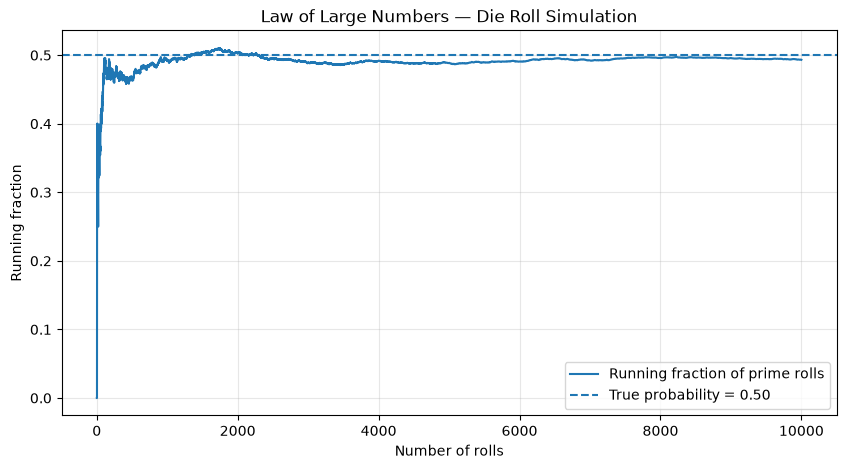


Law of Large Numbers: As the number of rolls increases, the running fraction gets closer to the true probability.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# TASK 01 — Events, Probabilities, and Law of Large Numbers
# ============================================================

# One RNG for reproducible simulations
rng = np.random.default_rng(0)


# ------------------------------------------------------------
# 1. Sample Space
# ------------------------------------------------------------
# A standard die can produce one of six outcomes.
sample_space = np.array([1, 2, 3, 4, 5, 6])

print("Sample Space:", sample_space)


# ------------------------------------------------------------
# 2. Define the Events
# ------------------------------------------------------------

# Event A: rolling a number greater than 4
event_greater_than_4 = sample_space[sample_space > 4]

# Event B: rolling a prime number
# 1 is NOT prime, so the prime numbers on a die are 2, 3 and 5.
event_prime = sample_space[np.isin(sample_space, [2, 3, 5])]

print("Event (number > 4):", event_greater_than_4)
print("Event (prime):", event_prime)


# ------------------------------------------------------------
# 3. Calculate Theoretical Probabilities by Counting
# ------------------------------------------------------------

p_greater_than_4 = len(event_greater_than_4) / len(sample_space)
p_prime = len(event_prime) / len(sample_space)

print("\nTheoretical probabilities:")
print("P(number > 4) =", p_greater_than_4)
print("P(prime)      =", p_prime)


# ------------------------------------------------------------
# 4. Monte Carlo Simulation — 10,000 Rolls
# ------------------------------------------------------------

rolls = rng.integers(1, 7, size=10_000)

# Check which rolls satisfy each event
greater_than_4 = rolls > 4
prime = np.isin(rolls, [2, 3, 5])

# Mean of Boolean values gives the fraction of True values
simulated_greater_than_4 = greater_than_4.mean()
simulated_prime = prime.mean()

print("\nSimulated probabilities after 10,000 rolls:")
print("P(number > 4) simulated =", simulated_greater_than_4)
print("P(prime) simulated      =", simulated_prime)


# ------------------------------------------------------------
# 5. Compare Theoretical vs Simulated Probability
# ------------------------------------------------------------

print("\nComparison:")
print(
    "Number > 4 difference:",
    abs(p_greater_than_4 - simulated_greater_than_4)
)

print(
    "Prime difference:",
    abs(p_prime - simulated_prime)
)


# ------------------------------------------------------------
# 6. Running Fraction for Prime Rolls
# ------------------------------------------------------------

# np.cumsum(prime) counts how many prime rolls occurred so far.
# Dividing by 1, 2, 3, ..., 10,000 gives the running fraction.
running_fraction = np.cumsum(prime) / np.arange(1, len(rolls) + 1)


# ------------------------------------------------------------
# 7. Plot the Running Fraction
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(1, len(rolls) + 1),
    running_fraction,
    label="Running fraction of prime rolls"
)

plt.axhline(
    p_prime,
    linestyle="--",
    label=f"True probability = {p_prime:.2f}"
)

plt.xlabel("Number of rolls")
plt.ylabel("Running fraction")
plt.title("Law of Large Numbers — Die Roll Simulation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ------------------------------------------------------------
# 8. Law of Large Numbers
# ------------------------------------------------------------

print(
    "\nLaw of Large Numbers:",
    "As the number of rolls increases, the running fraction "
    "gets closer to the true probability."
)